# Lab 4-3: 지도학습의 4대 Challenging Problems 체감 실습

본 실습에서는 지도학습 모델을 실제 현장에 적용할 때 직면하게 되는 **4대 핵심 문제(Challenging Problems)**를 직접 구현하고 비교 실험하여 체감합니다.

---

### [학습 목표]
1. **기울기 소실 문제 (Vanishing Gradient)**: 깊은 신경망(20층)에서 Sigmoid 사용 시 역전파 기울기가 소실되어 학습이 중단되는 현상을 체감하고, ReLU로의 전환 효과를 확인합니다.
2. **과적합 문제 (Overfitting - 모델 복잡도)**: 동일한 데이터셋에서 단순한 모델과 복잡한(파라미터가 많은) 모델의 일반화 격차(Train vs Val Loss)를 비교합니다.
3. **레이블 데이터 부족 문제 (Overfitting - 데이터 크기)**: 복잡한 신경망에 작은 데이터셋(100개)과 충분한 데이터셋(2000개)을 적용했을 때의 과적합 차이를 체감합니다.
4. **클래스 불균형 문제 (Class Imbalance)**: 다수 클래스 90%, 소수 클래스 10% 불균형 데이터에서 전체 Accuracy 90%라는 '정확도의 함정'을 확인하고, 균형 잡힌 테스트셋 검증을 통해 모델의 실체를 체감합니다.


In [1]:
%matplotlib inline
import os
import logging
import platform
import numpy as np
import matplotlib.pyplot as plt
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
import tensorflow as tf
from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

tf.get_logger().setLevel("ERROR")
logging.getLogger("tensorflow").setLevel(logging.ERROR)

if platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":
    plt.rc("font", family="AppleGothic")
else:
    plt.rc("font", family="NanumGothic")
plt.rcParams["axes.unicode_minus"] = False

# 시드 고정
tf.random.set_seed(42)
np.random.seed(42)

# Apple Silicon: CUDA가 아니라 Metal(MPS) GPU를 사용합니다.
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)
    print("학습 장치: MPS (Apple GPU)", gpus)
else:
    print("학습 장치: CPU (GPU/MPS 미검출)")
print("TensorFlow 버전:", tf.__version__)


학습 장치: MPS (Apple GPU) [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow 버전: 2.17.1


---
## Part 1. 기울기 소실 문제 (Vanishing Gradient Problem)

역전파(Backpropagation) 과정에서 연쇄 법칙(Chain Rule)에 의해 미분값이 누적 곱셈됩니다.
Sigmoid 활성화 함수의 도함수 최댓값은 $0.25$이므로, 층이 깊어질수록 출력층의 기울기가 입력층 방향으로 가면서 지수적으로 $0$에 수렴합니다.

- **실험 1-1**: 20층 Sigmoid 심층망 vs 3층 Sigmoid 천층망 학습 비교
- **실험 1-2**: 20층 Sigmoid 심층망 vs 20층 ReLU 심층망 학습 비교


### 1-1. 데이터셋 준비 (`make_moons`)
2개의 초승달 모양으로 분포된 비선형 이진 분류 데이터셋을 생성하고 표준화(StandardScaler)를 수행합니다.


In [2]:
# make_moons 데이터셋 (2000개 샘플)
X, y = make_moons(n_samples=2000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"X_train 형태: {X_train.shape}, y_train 분포: {np.bincount(y_train)}")


X_train 형태: (1600, 2), y_train 분포: [803 797]


### 1-2. 모델 생성 함수 정의 (깊은 망 vs 얕은 망)


In [3]:
def build_deep_model(activation="sigmoid", layers=20):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(2,)))
    for _ in range(layers):
        # [TODO] 32개 뉴런과 전달받은 activation을 사용하는 Dense 레이어를 추가하세요.
        model.add(tf.keras.layers.Dense(32, activation=activation))
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def build_shallow_model(activation="sigmoid", layers=3):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(2,)))
    for _ in range(layers):
        # [TODO] 32개 뉴런과 전달받은 activation을 사용하는 Dense 레이어를 추가하세요.
        model.add(tf.keras.layers.Dense(32, activation=activation))
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


### 1-3. 깊은 네트워크(20층) vs 얕은 네트워크(3층) Sigmoid 학습 및 비교


1. 깊은 망(20층 Sigmoid) 학습 중...


2. 얕은 망(3층 Sigmoid) 학습 중...


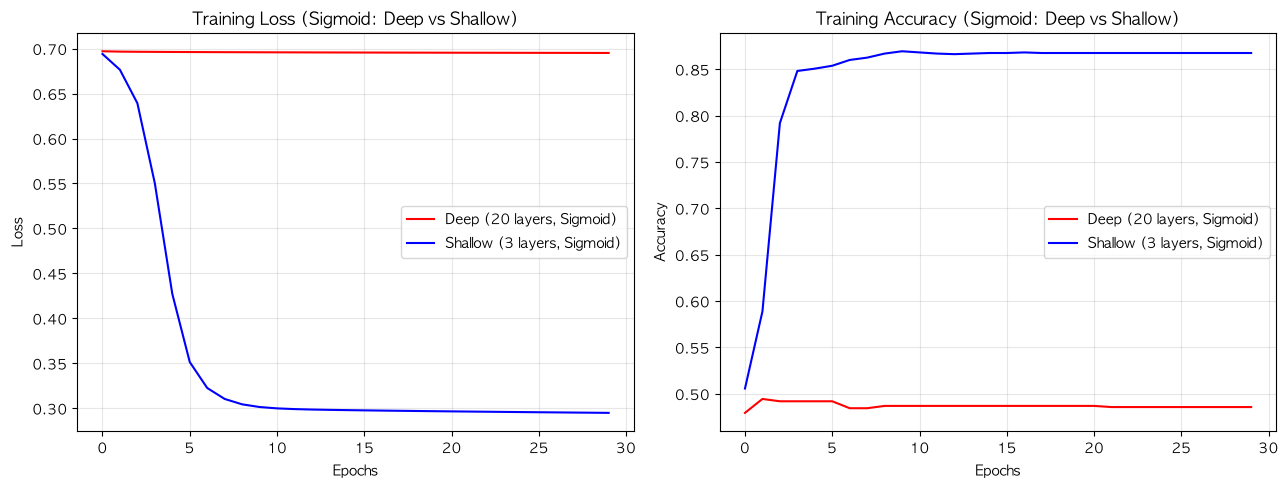

In [4]:
# 깊은 네트워크 (20층 Sigmoid)
print("1. 깊은 망(20층 Sigmoid) 학습 중...")
deep_model = build_deep_model(activation="sigmoid", layers=20)
history_deep = deep_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=32, verbose=0)

# 얕은 네트워크 (3층 Sigmoid)
print("2. 얕은 망(3층 Sigmoid) 학습 중...")
shallow_model = build_shallow_model(activation="sigmoid", layers=3)
history_shallow = shallow_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=32, verbose=0)

# 비교 시각화
plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.plot(history_deep.history['loss'], label="Deep (20 layers, Sigmoid)", color='red')
plt.plot(history_shallow.history['loss'], label="Shallow (3 layers, Sigmoid)", color='blue')
plt.title("Training Loss (Sigmoid: Deep vs Shallow)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_deep.history['accuracy'], label="Deep (20 layers, Sigmoid)", color='red')
plt.plot(history_shallow.history['accuracy'], label="Shallow (3 layers, Sigmoid)", color='blue')
plt.title("Training Accuracy (Sigmoid: Deep vs Shallow)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 1-4. ReLU 활성화 함수로 개선된 깊은 네트워크 학습 비교
Sigmoid 대신 양수 영역에서 기울기가 1로 유지되는 ReLU 활성화 함수를 20층 신경망에 적용해봅니다.


3. 깊은 망(20층 ReLU) 학습 중...


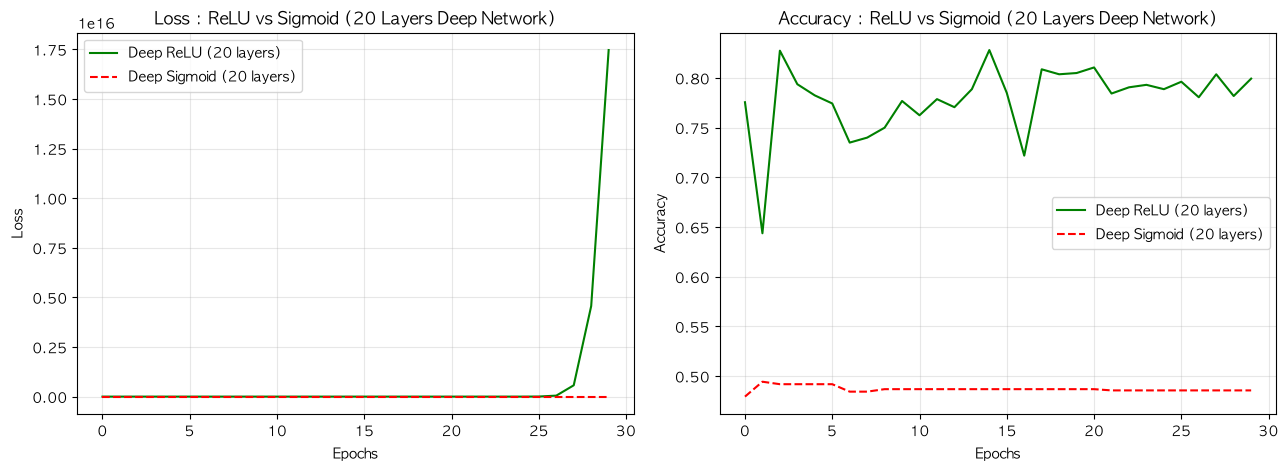

In [5]:
print("3. 깊은 망(20층 ReLU) 학습 중...")
relu_deep = build_deep_model(activation="relu", layers=20)
relu_history = relu_deep.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=32, verbose=0)

plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.plot(relu_history.history['loss'], label="Deep ReLU (20 layers)", color='green')
plt.plot(history_deep.history['loss'], label="Deep Sigmoid (20 layers)", color='red', linestyle='--')
plt.title("Loss : ReLU vs Sigmoid (20 Layers Deep Network)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(relu_history.history['accuracy'], label="Deep ReLU (20 layers)", color='green')
plt.plot(history_deep.history['accuracy'], label="Deep Sigmoid (20 layers)", color='red', linestyle='--')
plt.title("Accuracy : ReLU vs Sigmoid (20 Layers Deep Network)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 💡 [생각해보기 - 기울기 소실]
1. 20층 Sigmoid 망에서 손실함수(Loss)와 정확도(Accuracy)가 30 Epoch 동안 거의 변하지 않은 이유는 무엇일까요?
2. 3층 Sigmoid 망은 정상적으로 학습된 반면, 20층 Sigmoid 망에서만 학습 정체가 일어난 이유를 역전파의 연쇄 법칙(Chain Rule) 관점에서 설명해보세요.
3. 20층 구조임에도 ReLU 함수를 사용했을 때 즉각 학습이 잘 진행되는 이유는 무엇일까요?


**나의 답변:**

1. Sigmoid의 도함수는 커봐야 0.25라서, 뒤로 넘길수록 기울기가 계속 작아진다.  
   그 결과 20층까지 가면 앞쪽 가중치는 거의 안 바뀌고, Loss와 Accuracy가 30 Epoch 동안 그대로다.

2. 역전파는 각 층의 도함수를 곱해서 앞으로 보낸다.  
   따라서 3층은 곱하는 횟수가 적어서 기울기가 남아 학습이 되지만,  
   반면 20층은 0.25를 여러 번 곱하다 보니 입력 쪽 기울기가 거의 0이 된다.

3. ReLU는 값이 양수일 때 도함수가 1이라 층을 많이 쌓아도 기울기가 잘 살아 있다.  
   그래서 똑같이 20층이어도 ReLU면 바로 학습이 된다.


---
## Part 2. 과적합 문제 (Overfitting Problem - 모델 복잡도 관점)

동일한 작은 크기의 데이터셋(300개)에 대해 단순한 모델(파라미터 소수)과 복잡한 모델(파라미터 다수)을 비교합니다.
- 단순 모델: 은닉층 8개 노드 1개
- 복잡한 모델: 은닉층 128개 노드 3개


In [6]:
# 데이터 준비 (300개 샘플)
X_overfit, y_overfit = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train_of, X_test_of, y_train_of, y_test_of = train_test_split(X_overfit, y_overfit, test_size=0.3, random_state=42)

scaler_of = StandardScaler()
X_train_of = scaler_of.fit_transform(X_train_of)
X_test_of = scaler_of.transform(X_test_of)

print(f"과적합 실습 학습용 데이터 수: {len(X_train_of)}, 검증용 데이터 수: {len(X_test_of)}")


과적합 실습 학습용 데이터 수: 210, 검증용 데이터 수: 90


### 2-1. 단순 모델과 복잡한 모델 정의


In [7]:
def build_simple_model():
    # [TODO] 8개 유닛(relu), 출력 1개(sigmoid)를 갖는 단순 모델 구성
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(2,)),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def build_complex_model():
    # [TODO] 128개 유닛(relu) 은닉층 3개를 갖는 복잡한 모델 구성
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(2,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


### 2-2. 두 모델 학습 및 Train vs Val 곡선 비교


1. 단순 모델(Simple Model) 학습...


2. 복잡한 모델(Complex Model) 학습...


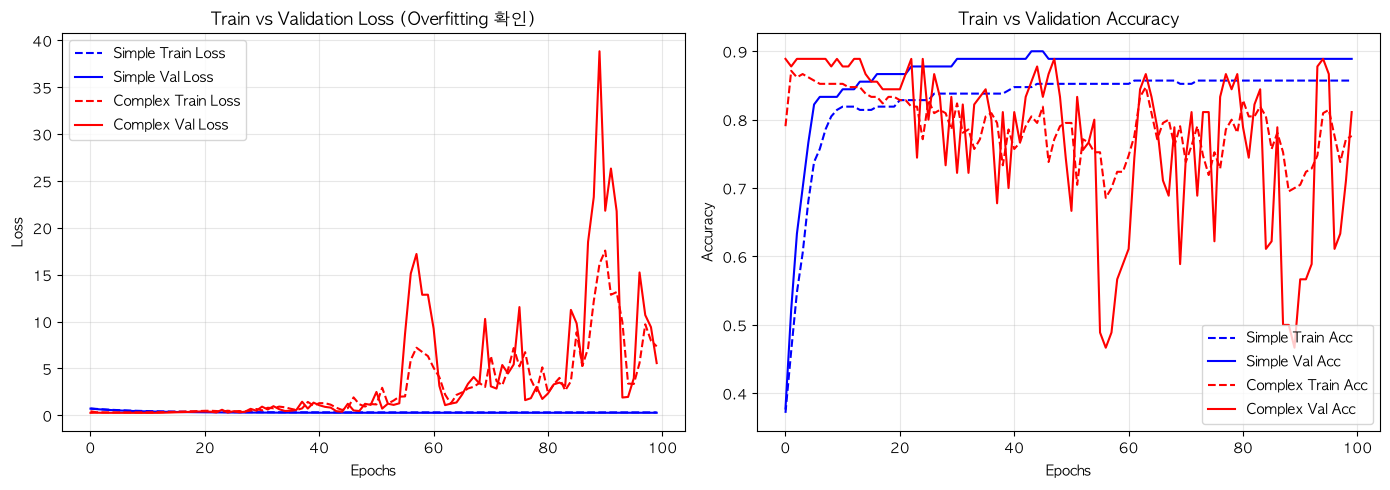

In [8]:
simple_model = build_simple_model()
complex_model = build_complex_model()

print("1. 단순 모델(Simple Model) 학습...")
history_simple = simple_model.fit(
    X_train_of, y_train_of, validation_data=(X_test_of, y_test_of),
    epochs=100, batch_size=16, verbose=0
)

print("2. 복잡한 모델(Complex Model) 학습...")
history_complex = complex_model.fit(
    X_train_of, y_train_of, validation_data=(X_test_of, y_test_of),
    epochs=100, batch_size=16, verbose=0
)

# 학습 곡선 시각화
plt.figure(figsize=(14, 5))

# Loss 비교
plt.subplot(1, 2, 1)
plt.plot(history_simple.history["loss"], label="Simple Train Loss", color="blue", linestyle="--")
plt.plot(history_simple.history["val_loss"], label="Simple Val Loss", color="blue")
plt.plot(history_complex.history["loss"], label="Complex Train Loss", color="red", linestyle="--")
plt.plot(history_complex.history["val_loss"], label="Complex Val Loss", color="red")
plt.title("Train vs Validation Loss (Overfitting 확인)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy 비교
plt.subplot(1, 2, 2)
plt.plot(history_simple.history["accuracy"], label="Simple Train Acc", color="blue", linestyle="--")
plt.plot(history_simple.history["val_accuracy"], label="Simple Val Acc", color="blue")
plt.plot(history_complex.history["accuracy"], label="Complex Train Acc", color="red", linestyle="--")
plt.plot(history_complex.history["val_accuracy"], label="Complex Val Acc", color="red")
plt.title("Train vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 💡 [생각해보기 - 모델 복잡도 과적합]
1. 복잡한 모델의 그래프에서 `Train Loss`는 계속 감소하지만 `Val Loss`는 특정 에포크 이후 다시 치솟는 현상이 나타납니다. 이 시점의 의미는 무엇일까요?
2. 단순한 모델과 복잡한 모델 중 테스트 데이터에 대한 일반화(Generalization) 성능이 더 안정적인 모델은 어느 쪽인가요?


**나의 답변:**

1. Train Loss는 계속 떨어지는데 Val Loss가 다시 올라가기 시작하는 때가 과적합이 시작된 지점이다.  
   즉 학습 데이터만 외우기 시작했다는 뜻이라, 그 직전에서 학습을 멈추는 게 Early Stopping이다.

2. 데이터가 300개뿐이면 단순한 모델이 더 믿을 만하다.  
   반면 복잡한 모델은 학습 곡선만 보면 잘된 것 같아도 Val Loss가 튀어서 테스트 성능이 들쭉날쭉하다.


---
## Part 3. 레이블 데이터 부족 문제 (Overfitting vs Dataset Size)

제조 공정에서는 정상 데이터는 풍부하지만, 고비용의 라벨링 작업으로 인해 **레이블 데이터가 부족(Few Labeled Data)**한 경우가 매우 빈번합니다.
동일한 복잡한 모델을 작은 데이터셋(100개)과 큰 데이터셋(2000개)에 각각 학습시켜 데이터 크기가 과적합에 미치는 영향을 확인합니다.


In [9]:
# 1. 작은 데이터셋 (100개)
X_small, y_small = make_moons(n_samples=100, noise=0.25, random_state=42)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_small, y_small, test_size=0.3, random_state=42)

# 2. 큰 데이터셋 (2000개)
X_large, y_large = make_moons(n_samples=2000, noise=0.25, random_state=42)
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_large, y_large, test_size=0.3, random_state=42)

# 스케일링
scaler_s = StandardScaler()
X_train_s = scaler_s.fit_transform(X_train_s)
X_test_s = scaler_s.transform(X_test_s)

scaler_l = StandardScaler()
X_train_l = scaler_l.fit_transform(X_train_l)
X_test_l = scaler_l.transform(X_test_l)

print(f"작은 데이터셋 학습 샘플 수: {len(X_train_s)}, 큰 데이터셋 학습 샘플 수: {len(X_train_l)}")


작은 데이터셋 학습 샘플 수: 70, 큰 데이터셋 학습 샘플 수: 1400


### 3-1. 작은 데이터셋 vs 큰 데이터셋 동일 모델 학습


1. 작은 데이터셋(100개 샘플)으로 복잡 모델 학습...


2. 큰 데이터셋(2000개 샘플)으로 복잡 모델 학습...


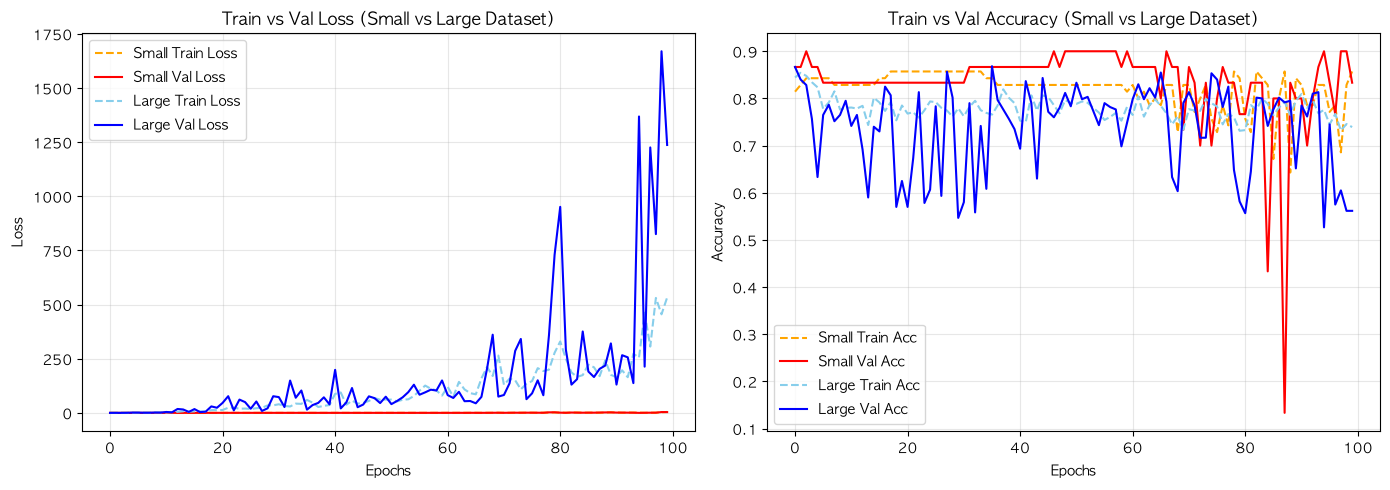

In [10]:
# 작은 데이터셋 학습
print("1. 작은 데이터셋(100개 샘플)으로 복잡 모델 학습...")
model_small = build_complex_model()
history_small = model_small.fit(
    X_train_s, y_train_s, validation_data=(X_test_s, y_test_s),
    epochs=100, batch_size=16, verbose=0
)

# 큰 데이터셋 학습
print("2. 큰 데이터셋(2000개 샘플)으로 복잡 모델 학습...")
model_large = build_complex_model()
history_large = model_large.fit(
    X_train_l, y_train_l, validation_data=(X_test_l, y_test_l),
    epochs=100, batch_size=16, verbose=0
)

# 학습 결과 비교 시각화
plt.figure(figsize=(14, 5))

# Loss 비교
plt.subplot(1, 2, 1)
plt.plot(history_small.history["loss"], label="Small Train Loss", color="orange", linestyle="--")
plt.plot(history_small.history["val_loss"], label="Small Val Loss", color="red")
plt.plot(history_large.history["loss"], label="Large Train Loss", color="skyblue", linestyle="--")
plt.plot(history_large.history["val_loss"], label="Large Val Loss", color="blue")
plt.title("Train vs Val Loss (Small vs Large Dataset)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy 비교
plt.subplot(1, 2, 2)
plt.plot(history_small.history["accuracy"], label="Small Train Acc", color="orange", linestyle="--")
plt.plot(history_small.history["val_accuracy"], label="Small Val Acc", color="red")
plt.plot(history_large.history["accuracy"], label="Large Train Acc", color="skyblue", linestyle="--")
plt.plot(history_large.history["val_accuracy"], label="Large Val Acc", color="blue")
plt.title("Train vs Val Accuracy (Small vs Large Dataset)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 💡 [생각해보기 - 데이터 크기]
1. 동일한 3층 128노드 복잡 모델임에도, 데이터셋의 크기가 100개에서 2000개로 증가했을 때 과적합 양상이 어떻게 달라졌나요?
2. 제조 현장에서 라벨링된 불량 데이터 샘플 수가 매우 적을 때, 딥러닝 모델의 파라미터 수를 무작정 늘리는 것이 왜 위험한지 설명해보세요.


**나의 답변:**

1. 데이터가 100개일 때는 Train Loss만 떨어지고 Val Loss는 벌어지거나 다시 올라 과적합이 잘 보인다.  
   하지만 2000개로 늘리면 두 곡선이 비슷하게 내려가서 격차가 줄어든다.  
   결국 모델이 같아도 데이터가 충분하면 일반화가 된다.

2. 라벨이 얼마 없는데 파라미터만 키우면 그 몇 개 샘플을 외우게 된다.  
   그래서 현장에서 처음 보는 불량에는 바로 틀리고, 데이터 모은 값에 비해 성능이 안 나온다.  
   따라서 데이터 규모에 맞는 단순한 모델이나 규제, 증강을 쓰는 편이 낫다.


---
## Part 4. 클래스 불균형 문제 (Class Imbalanced Problem)

제조 공정에서는 정상 제품(90~99% 이상)이 대다수이고 불량 제품(1~10% 이하)은 매우 드물게 발생합니다.
이러한 불균형 상태에서 표준 교차 엔트로피 손실로 학습하면 모델이 다수 클래스만 맞추려는 편향이 생깁니다.

- 데이터 구성: 0번 클래스(정상) 90%, 1번 클래스(불량) 10%
- 결과 관찰 1: 불균형 테스트셋 평가 시 전체 정확도(Accuracy)는 90% 이상으로 매우 높아 보이지만, 소수 클래스 재현율이 떨어지는 '정확도의 착시'를 체감합니다.
- 결과 관찰 2: **클래스 균형이 맞는 새로운 테스트셋(50:50)**을 주었을 때 모델의 실제 정확도가 급락하는 현상을 확인합니다.


In [11]:
# 불균형 데이터셋 생성 (Class 0: 90%, Class 1: 10%)
X_imb, y_imb = make_classification(
    n_samples=2000, n_features=20, n_informative=10, n_redundant=5,
    weights=[0.9, 0.1], n_classes=2, random_state=42
)

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
)

print("전체 클래스 분포:", np.bincount(y_imb))
print("학습용 클래스 분포:", np.bincount(y_train_imb))
print("검증용 클래스 분포:", np.bincount(y_test_imb))


전체 클래스 분포: [1792  208]
학습용 클래스 분포: [1254  146]
검증용 클래스 분포: [538  62]


### 4-1. 신경망 모델 정의 및 학습


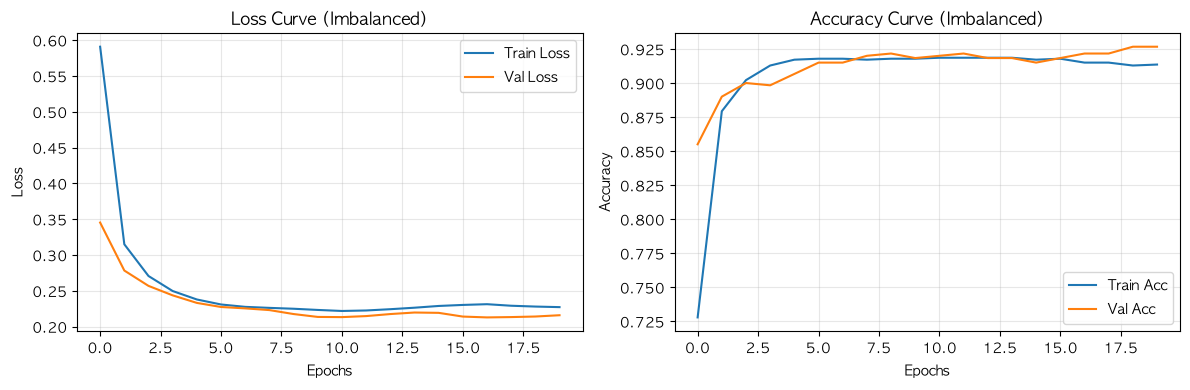

In [12]:
model_imb = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(20,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
model_imb.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_imb = model_imb.fit(
    X_train_imb, y_train_imb, validation_data=(X_test_imb, y_test_imb),
    epochs=20, batch_size=32, verbose=0
)

# 학습 곡선 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_imb.history["loss"], label="Train Loss")
plt.plot(history_imb.history["val_loss"], label="Val Loss")
plt.title("Loss Curve (Imbalanced)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_imb.history["accuracy"], label="Train Acc")
plt.plot(history_imb.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy Curve (Imbalanced)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 4-2. 불균형 테스트셋 평가 (Confusion Matrix와 Classification Report)


=== Classification Report (Imbalanced Test Data) ===
              precision    recall  f1-score   support

  Normal (0)     0.9379    0.9833    0.9601       538
  Defect (1)     0.7500    0.4355    0.5510        62

    accuracy                         0.9267       600
   macro avg     0.8440    0.7094    0.7555       600
weighted avg     0.9185    0.9267    0.9178       600



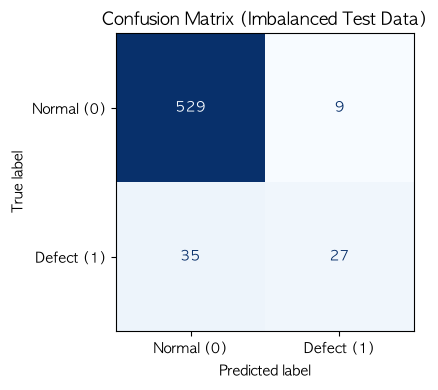

In [13]:
# [TODO] model_imb의 출력 확률에 대해 0.5 임계값을 적용하여 0 또는 1의 예측 라벨을 구하세요.
y_pred_prob = model_imb.predict(X_test_imb, verbose=0)
y_pred_imb = (y_pred_prob > 0.5).astype(int).flatten()

print("=== Classification Report (Imbalanced Test Data) ===")
print(classification_report(y_test_imb, y_pred_imb, digits=4, target_names=["Normal (0)", "Defect (1)"]))

# [TODO] confusion_matrix를 계산하고 ConfusionMatrixDisplay로 시각화하세요.
cm = confusion_matrix(y_test_imb, y_pred_imb)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal (0)", "Defect (1)"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Imbalanced Test Data)")
plt.tight_layout()
plt.show()


### 4-3. 클래스 균형이 맞는 새로운 데이터셋으로 평가 (진짜 성능 체감)

학습할 때는 90:10 불균형 데이터로 학습된 모델에게, **클래스 비율이 50:50인 새로운 균형 잡힌 테스트 데이터셋(100개)**을 입력했을 때 어떻게 동작하는지 확인합니다.


새로운 균형 테스트셋 클래스 분포: [50 50]

=== Classification Report (Balanced Test Data) ===
              precision    recall  f1-score   support

     Class 0     0.4247    0.6200    0.5041        50
     Class 1     0.2963    0.1600    0.2078        50

    accuracy                         0.3900       100
   macro avg     0.3605    0.3900    0.3559       100
weighted avg     0.3605    0.3900    0.3559       100



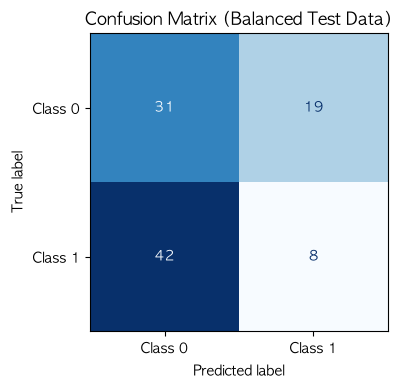

In [14]:
# 균형 잡힌 새로운 테스트 데이터 생성 (Class 0: 50%, Class 1: 50%)
X_test_bal, y_test_bal = make_classification(
    n_samples=100, n_features=20, n_informative=10, n_redundant=5, n_classes=2, random_state=42
)

print(f"새로운 균형 테스트셋 클래스 분포: {np.bincount(y_test_bal)}")

# [TODO] model_imb를 사용하여 새로운 균형 테스트셋에 대한 예측값을 계산하세요.
y_pred_bal = (model_imb.predict(X_test_bal, verbose=0) > 0.5).astype(int).flatten()

print("\n=== Classification Report (Balanced Test Data) ===")
print(classification_report(y_test_bal, y_pred_bal, digits=4, target_names=["Class 0", "Class 1"]))

# [TODO] confusion_matrix를 계산하고 시각화하세요.
cm_bal = confusion_matrix(y_test_bal, y_pred_bal)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=["Class 0", "Class 1"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Balanced Test Data)")
plt.tight_layout()
plt.show()


### 💡 [생각해보기 - 클래스 불균형과 정확도의 착시]
1. 불균형 테스트셋에서는 정확도가 **96%**로 높게 나왔지만, 균형 잡힌 새로운 테스트 데이터셋(50:50)에 적용했을 때 정확도가 어떻게 변화했나요?
2. Accuracy(정확도) 지표가 데이터셋의 클래스 분포에 따라 왜 왜곡된 성능 착시를 일으키는지 설명해보세요.
3. 불균형 분류 문제를 해결하기 위해 다음 실습(Lab 4-4)에서 다루는 Class Weighting이나 Balanced Data Augmentation이 왜 필수적인지 생각해보세요.


**나의 답변:**

1. 이번 실행에서는 불균형 테스트 정확도가 약 92.7%로 높아 보였다(불량 재현율 0.44).  
   그런데 정상과 불량을 반반 섞은 테스트에서는 정확도가 약 39%까지 떨어졌고,  
   게다가 불량 재현율도 0.16이라 현장에 그대로 쓰면 불량을 대부분 놓친다.

2. Accuracy는 맞춘 개수를 전체로 나눈 값이라, 정상이 90%면 정상만 찍어도 90%가 나온다.  
   따라서 불량을 거의 못 찾아도 점수만 보면 잘된 것처럼 보인다.

3. Class Weight는 소수 클래스 실수를 더 크게 보고,  
   또한 Balanced Augmentation은 소수 샘플을 늘려 학습이 한쪽으로 치우치지 않게 한다.  
   그러므로 정확도 착시를 줄이고 불량 재현율과 F1을 올리려면 4-4에서 다루는 이 기법들이 필요하다.
